# Classifier-Free Guidance (CFG) for MNIST

This notebook demonstrates Classifier-Free Guidance - a technique for class-conditional image generation.

## Overview
- **Classifier-Free Guidance**: Conditions the diffusion model on class labels without a separate classifier
- **Two Conditioning Methods**: 
  - Input Concatenation: Spatially tiled class embeddings concatenated with input
  - Cross-Attention: Class embeddings used as context in cross-attention layers
- **CFG Training**: Model learns both conditional and unconditional generation
- **CFG Sampling**: Outputs interpolated based on guidance scale for quality/diversity tradeoff

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

from ddpm import DDPMCFG
from utils import show_imgs

# Set random seed for reproducibility
pl.seed_everything(42)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Seed set to 42


Using device: cuda


## 1. Prepare Data

In [3]:
# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets
train_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST('../data', train=False, download=True, transform=transform)

# Create dataloaders
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4,
    persistent_workers=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 60000
Validation samples: 10000


## 2. Visualize Training Data with Labels

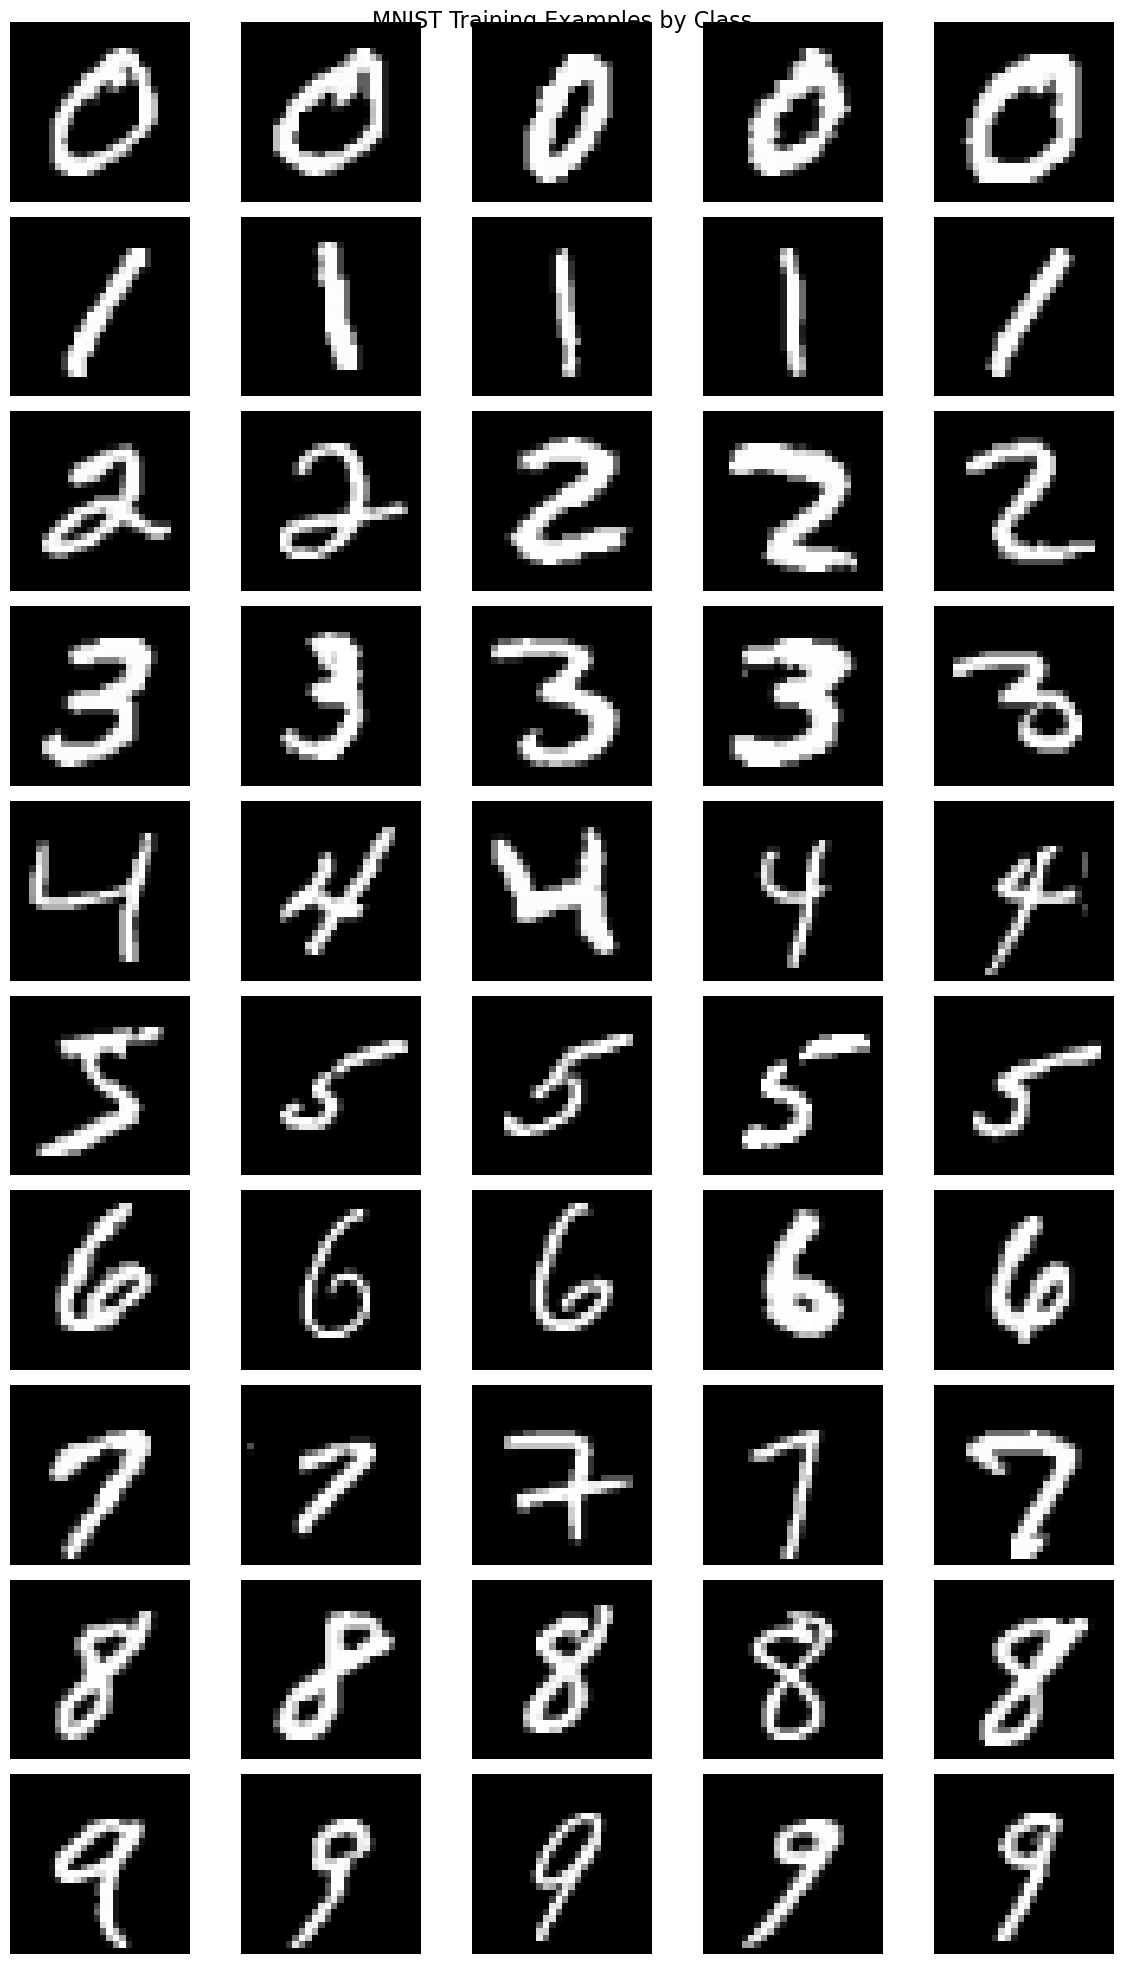

In [4]:
# Show some examples from each class
examples_per_class = 5
fig, axes = plt.subplots(10, examples_per_class, figsize=(12, 20))

# Collect examples for each class
class_examples = {i: [] for i in range(10)}
for img, label in train_dataset:
    if len(class_examples[label]) < examples_per_class:
        class_examples[label].append(img)
    if all(len(examples) >= examples_per_class for examples in class_examples.values()):
        break

# Plot examples
for class_idx in range(10):
    for example_idx in range(examples_per_class):
        ax = axes[class_idx, example_idx]
        ax.imshow(class_examples[class_idx][example_idx][0], cmap='gray')
        ax.axis('off')
        if example_idx == 0:
            ax.set_ylabel(f'Class {class_idx}', fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle('MNIST Training Examples by Class', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Train CFG Model with Input Concatenation

First, we'll train a model using input concatenation for conditioning.

In [5]:
# Create model with input concatenation
cfg_concat = DDPMCFG(
    in_channels=1,
    model_channels=64,
    channel_mult=(1, 2, 4),
    num_res_blocks=2,
    num_timesteps=1000,
    beta_start=1e-4,
    beta_end=0.02,
    beta_schedule='linear',
    lr=2e-4,
    num_inference_steps=50,
    num_classes=10,
    class_emb_dim=64,
    conditioning_type='concat',
    cfg_dropout=0.1,  # 10% unconditional training
    cfg_scale=3.0,
    dropout=0.1,
    num_heads=4
)

print(f"Model Parameters (Concat): {sum(p.numel() for p in cfg_concat.parameters()):,}")

Model Parameters (Concat): 14,200,961


In [6]:
# Training configuration
logger_concat = TensorBoardLogger("../lightning_logs", name="cfg_concat_mnist")

callbacks_concat = [
    ModelCheckpoint(
        monitor='val_loss',
        mode='min',
        save_top_k=3,
        filename='cfg-concat-{epoch:02d}-{val_loss:.4f}'
    ),
    LearningRateMonitor(logging_interval='epoch')
]

trainer_concat = pl.Trainer(
    max_epochs=100,
    accelerator='auto',
    devices=1,
    logger=logger_concat,
    callbacks=callbacks_concat,
    log_every_n_steps=10,
    gradient_clip_val=1.0
)

print("Starting CFG (Concat) training...")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting CFG (Concat) training...


In [7]:
# Train the model
trainer_concat.fit(cfg_concat, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 5090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type          | Params | Mode 
------------------------------------------------
0 | model | UNetCFGConcat | 14.2 M | train
------------------------------------------------
14.2 M    Trainable params
0         Non-trainable params
14.2 M    Total params
56.804    Total estimated model params size (MB)
290       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/xgeoadmin/miniconda3/envs/cuda-ml/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# Load best checkpoint
best_model_path_concat = trainer_concat.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path_concat}")

cfg_concat = DDPMCFG.load_from_checkpoint(best_model_path_concat).to(device)
cfg_concat.eval()
print("✓ Best concat model loaded")

## 4. Train CFG Model with Cross-Attention

Now, we'll train a model using cross-attention for conditioning.

In [9]:
# Create model with cross-attention
cfg_attn = DDPMCFG(
    in_channels=1,
    model_channels=64,
    channel_mult=(1, 2, 4),
    num_res_blocks=2,
    num_timesteps=1000,
    beta_start=1e-4,
    beta_end=0.02,
    beta_schedule='linear',
    lr=2e-4,
    num_inference_steps=50,
    num_classes=10,
    class_emb_dim=128,
    conditioning_type='cross_attn',
    cfg_dropout=0.1,
    cfg_scale=3.0,
    dropout=0.1,
    num_heads=4
)

print(f"Model Parameters (Cross-Attn): {sum(p.numel() for p in cfg_attn.parameters()):,}")

Model Parameters (Cross-Attn): 15,519,745


In [10]:
# Training configuration
logger_attn = TensorBoardLogger("../lightning_logs", name="cfg_attn_mnist")

callbacks_attn = [
    ModelCheckpoint(
        monitor='val_loss',
        mode='min',
        save_top_k=3,
        filename='cfg-attn-{epoch:02d}-{val_loss:.4f}'
    ),
    LearningRateMonitor(logging_interval='epoch')
]

trainer_attn = pl.Trainer(
    max_epochs=100,
    accelerator='auto',
    devices=1,
    logger=logger_attn,
    callbacks=callbacks_attn,
    log_every_n_steps=10,
    gradient_clip_val=1.0
)

print("Starting CFG (Cross-Attn) training...")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting CFG (Cross-Attn) training...


In [11]:
# Train the model
trainer_attn.fit(cfg_attn, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | UNetCFGCrossAttn | 15.5 M | train
---------------------------------------------------
15.5 M    Trainable params
0         Non-trainable params
15.5 M    Total params
62.079    Total estimated model params size (MB)
380       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [12]:
# Load best checkpoint
best_model_path_attn = trainer_attn.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path_attn}")

cfg_attn = DDPMCFG.load_from_checkpoint(best_model_path_attn).to(device)
cfg_attn.eval()
print("✓ Best cross-attention model loaded")

Loading best model from: ../lightning_logs/cfg_attn_mnist/version_0/checkpoints/cfg-attn-epoch=31-val_loss=0.0127.ckpt
✓ Best cross-attention model loaded


## 5. Class-Conditional Generation

Generate samples conditioned on specific classes.

Generating class-conditional samples (Concat model)...


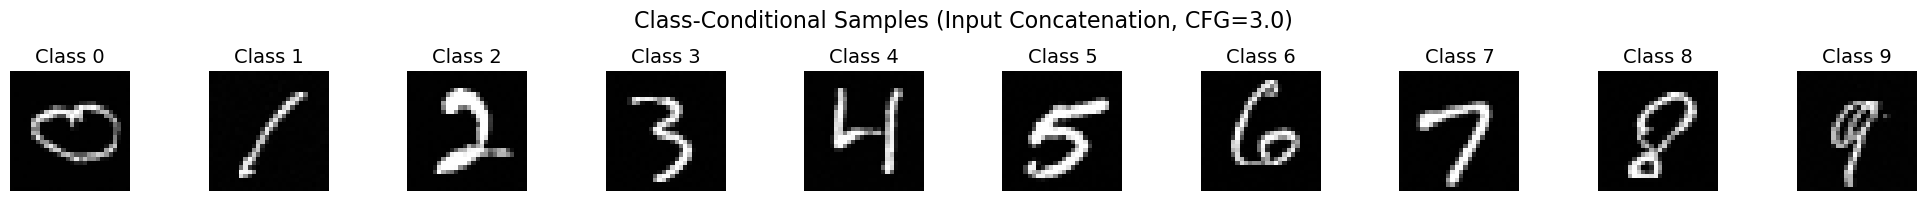

In [8]:
# Generate one sample per class using concat model
print("Generating class-conditional samples (Concat model)...")

class_labels = torch.arange(10).to(device)  # One of each digit

with torch.no_grad():
    samples_concat = cfg_concat.sample(
        num_samples=10,
        class_labels=class_labels,
        method='ddim',
        num_inference_steps=50,
        cfg_scale=3.0
    )

# Visualize
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    axes[i].imshow(samples_concat[i, 0].cpu(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Class {i}', fontsize=14)

plt.suptitle('Class-Conditional Samples (Input Concatenation, CFG=3.0)', fontsize=16)
plt.tight_layout()
plt.show()

Generating class-conditional samples (Cross-Attn model)...


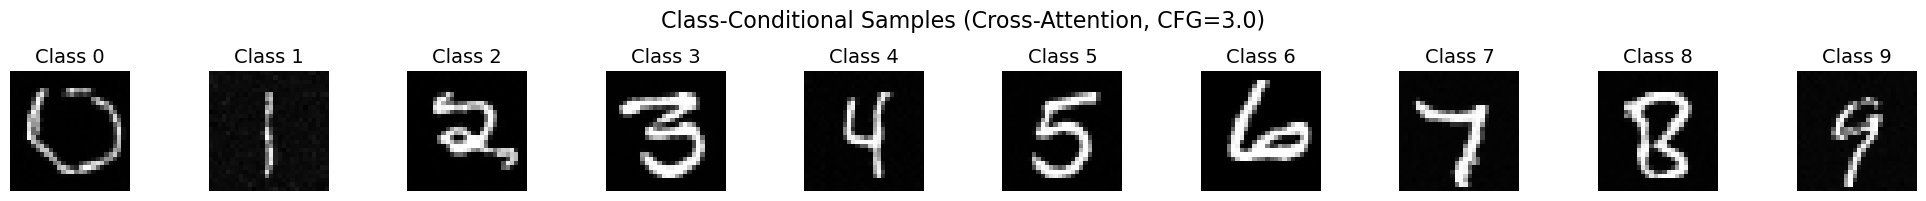

In [14]:
# Generate one sample per class using cross-attention model
print("Generating class-conditional samples (Cross-Attn model)...")

with torch.no_grad():
    samples_attn = cfg_attn.sample(
        num_samples=10,
        class_labels=class_labels,
        method='ddim',
        num_inference_steps=50,
        cfg_scale=3.0
    )

# Visualize
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    axes[i].imshow(samples_attn[i, 0].cpu(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Class {i}', fontsize=14)

plt.suptitle('Class-Conditional Samples (Cross-Attention, CFG=3.0)', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Effect of CFG Scale

Visualize how guidance scale affects image quality and diversity.

Generating samples with different CFG scales for class 3...


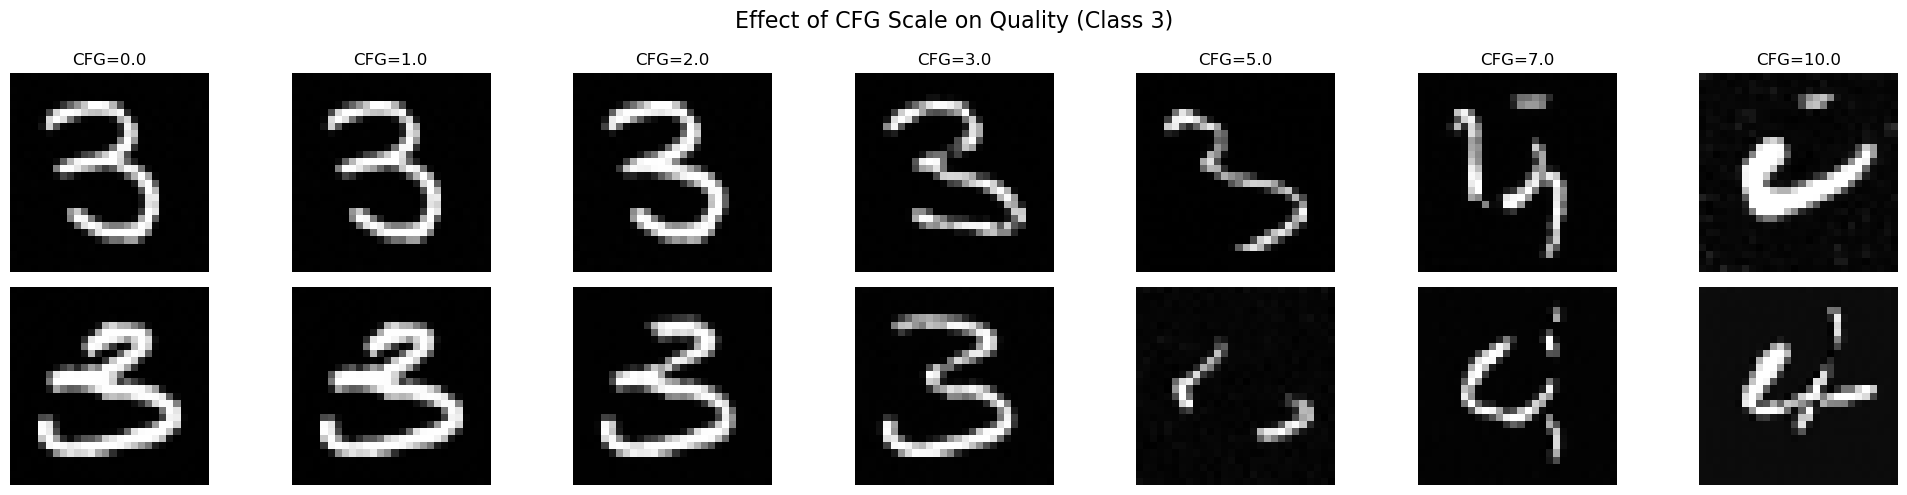


Observations:
- CFG = 0.0: Pure conditional, may be less sharp
- CFG = 1.0-3.0: Balanced quality and diversity
- CFG = 5.0-7.0: Higher quality, less diversity
- CFG = 10.0: Very high quality, but may lose diversity


In [15]:
# Test different CFG scales
cfg_scales = [0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
target_class = 3  # Generate digit '3'

print(f"Generating samples with different CFG scales for class {target_class}...")

fig, axes = plt.subplots(2, len(cfg_scales), figsize=(20, 5))

# Use same random seed for fair comparison
for i, scale in enumerate(cfg_scales):
    # Concat model
    torch.manual_seed(42)
    with torch.no_grad():
        sample_concat = cfg_concat.sample(
            num_samples=1,
            class_labels=torch.tensor([target_class]).to(device),
            method='ddim',
            num_inference_steps=50,
            cfg_scale=scale
        )
    
    axes[0, i].imshow(sample_concat[0, 0].cpu(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'CFG={scale}', fontsize=12)
    
    # Cross-attention model
    torch.manual_seed(42)
    with torch.no_grad():
        sample_attn = cfg_attn.sample(
            num_samples=1,
            class_labels=torch.tensor([target_class]).to(device),
            method='ddim',
            num_inference_steps=50,
            cfg_scale=scale
        )
    
    axes[1, i].imshow(sample_attn[0, 0].cpu(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Concat', fontsize=14, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('Cross-Attn', fontsize=14, rotation=0, ha='right', va='center')

plt.suptitle(f'Effect of CFG Scale on Quality (Class {target_class})', fontsize=16)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- CFG = 0.0: Pure conditional, may be less sharp")
print("- CFG = 1.0-3.0: Balanced quality and diversity")
print("- CFG = 5.0-7.0: Higher quality, less diversity")
print("- CFG = 10.0: Very high quality, but may lose diversity")

## 7. Diversity Analysis

Generate multiple samples per class to assess diversity.

Generating 5 samples per class (Cross-Attn, CFG=3.0)...


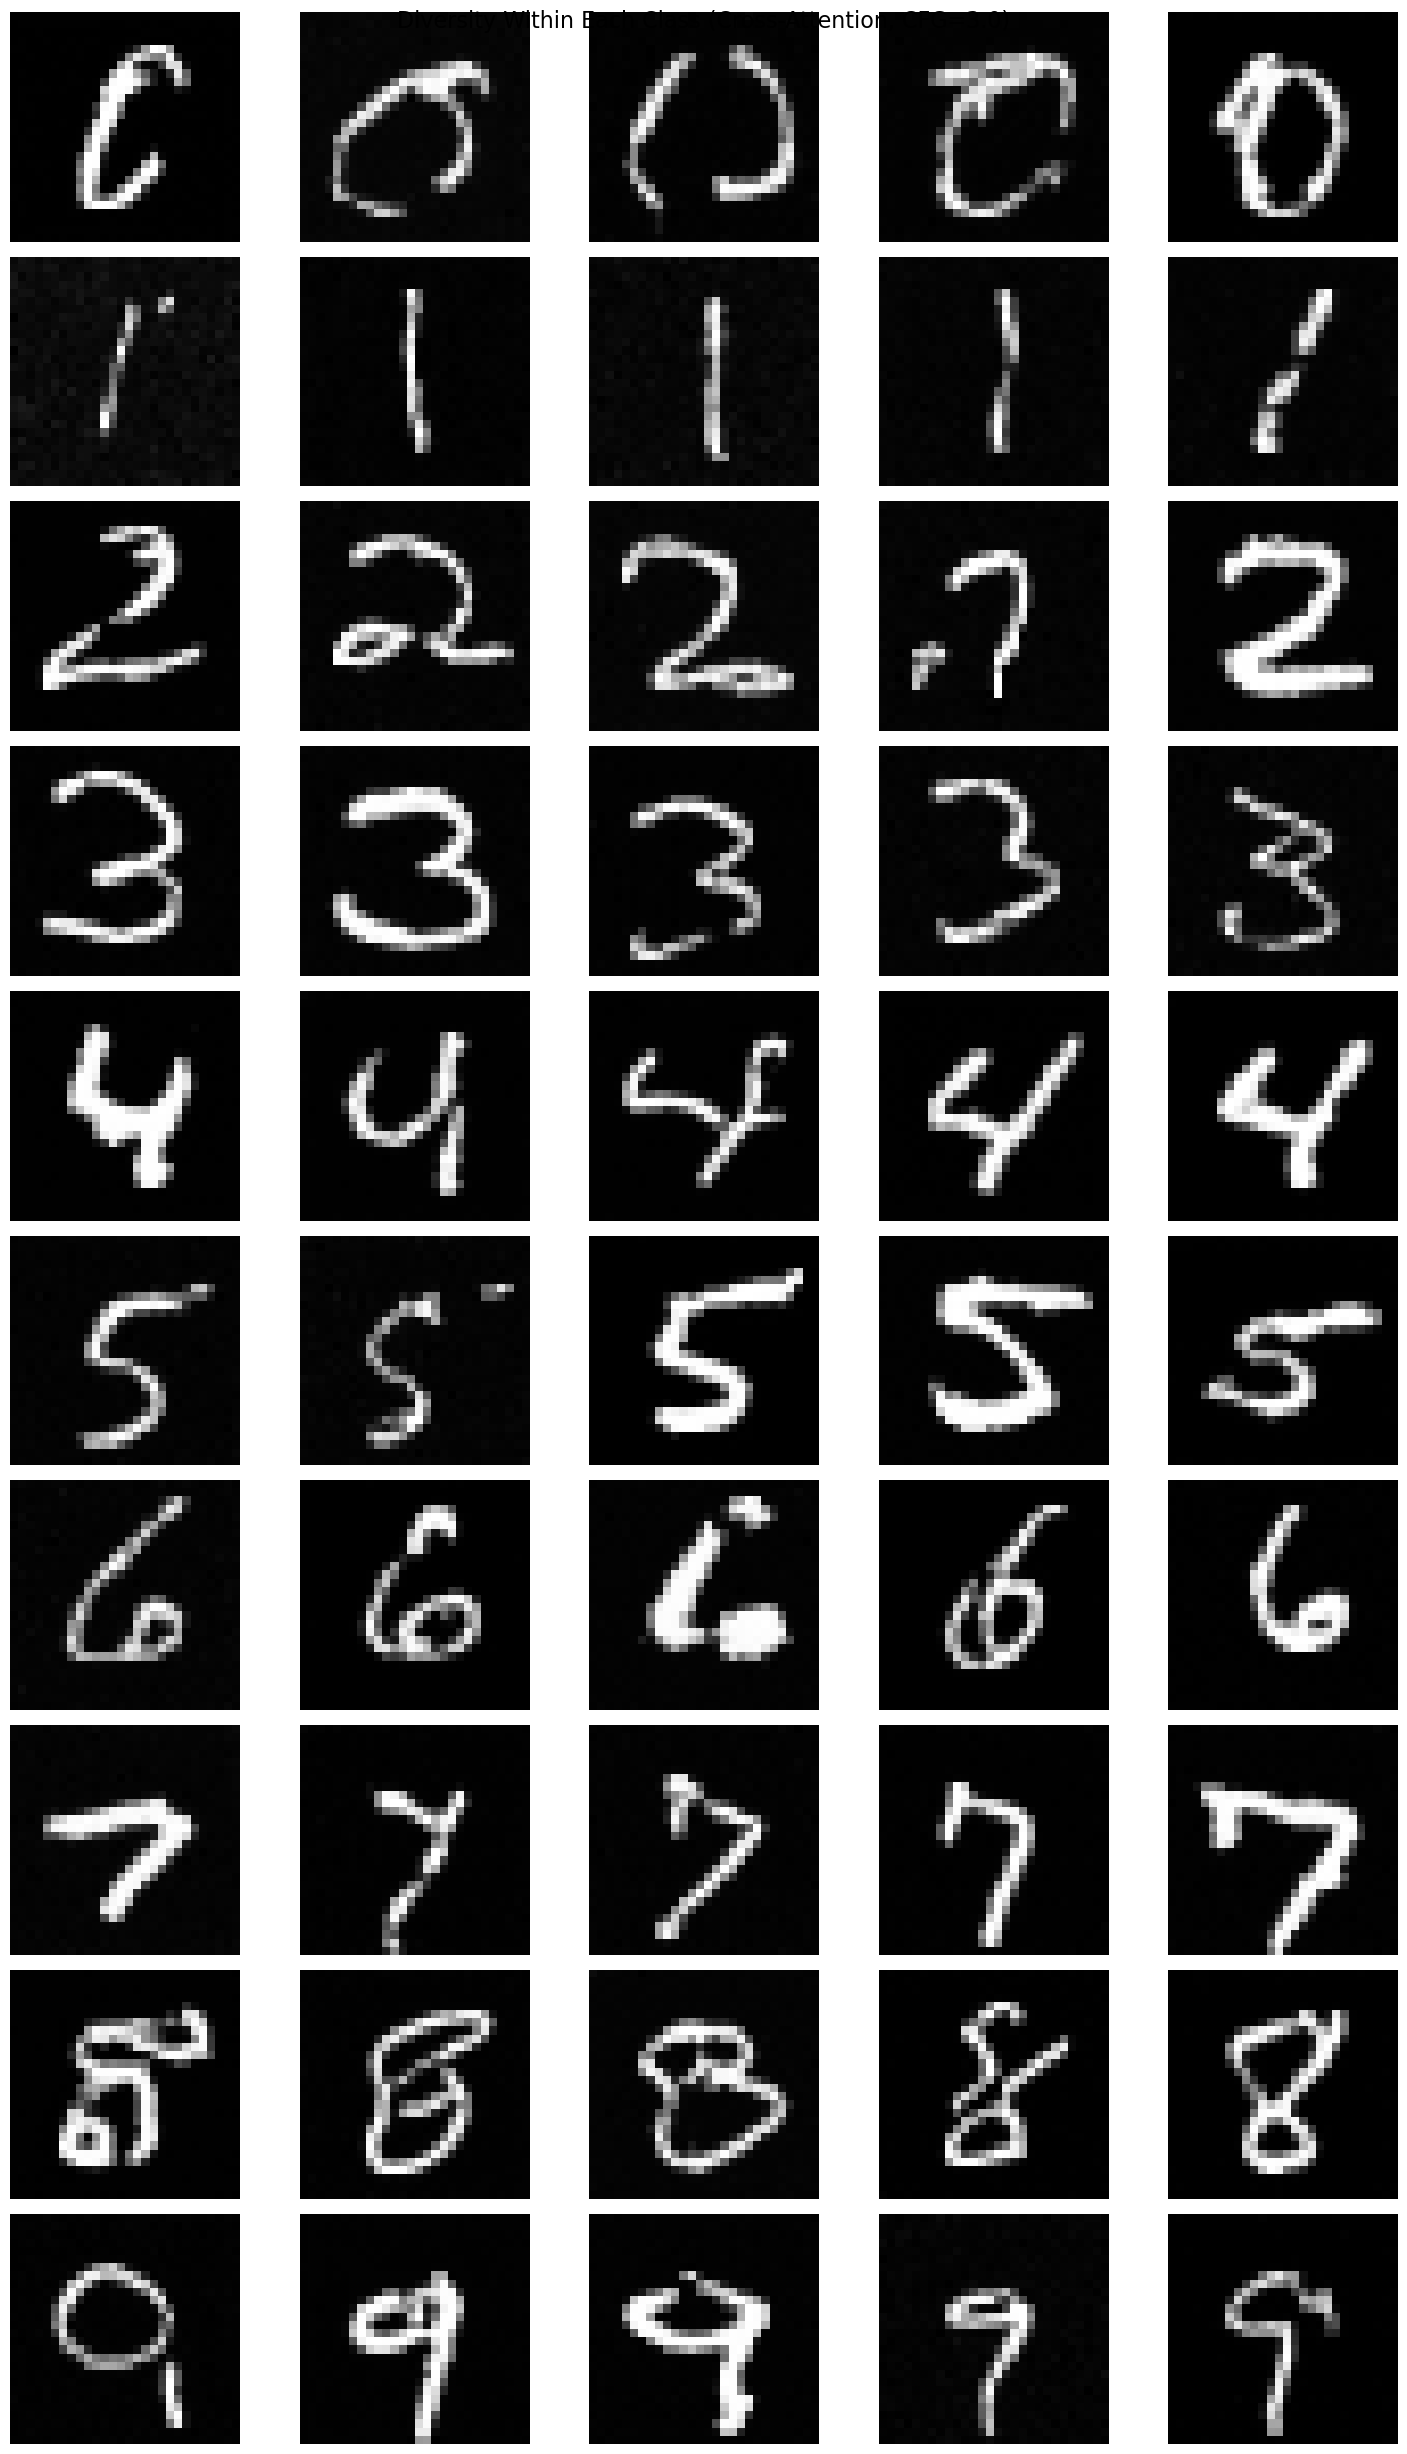

In [16]:
# Generate multiple samples per class
samples_per_class = 5
num_classes_show = 10

print(f"Generating {samples_per_class} samples per class (Cross-Attn, CFG=3.0)...")

fig, axes = plt.subplots(num_classes_show, samples_per_class, figsize=(15, 25))

for class_idx in range(num_classes_show):
    class_labels = torch.full((samples_per_class,), class_idx).to(device)
    
    with torch.no_grad():
        samples = cfg_attn.sample(
            num_samples=samples_per_class,
            class_labels=class_labels,
            method='ddim',
            num_inference_steps=50,
            cfg_scale=3.0
        )
    
    for sample_idx in range(samples_per_class):
        ax = axes[class_idx, sample_idx]
        ax.imshow(samples[sample_idx, 0].cpu(), cmap='gray')
        ax.axis('off')
        if sample_idx == 0:
            ax.set_ylabel(f'Class {class_idx}', fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle('Diversity Within Each Class (Cross-Attention, CFG=3.0)', fontsize=16)
plt.tight_layout()
plt.show()

## 8. Compare Conditioning Methods

Side-by-side comparison of input concatenation vs cross-attention.

Comparing conditioning methods...


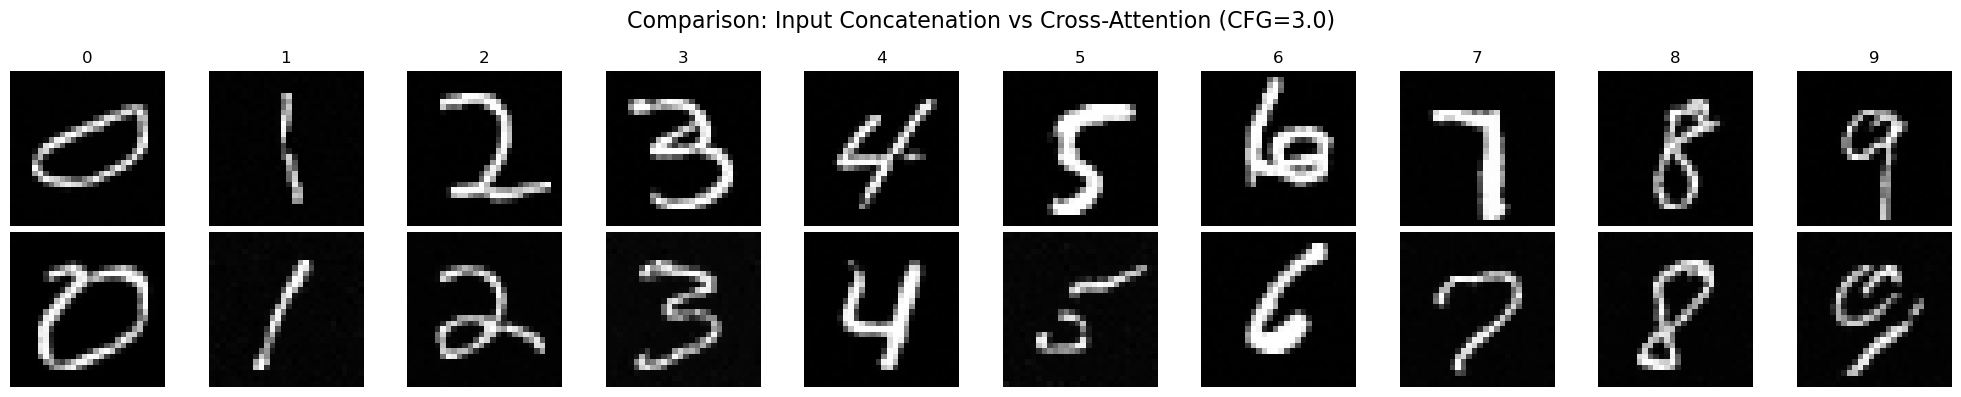

In [17]:
# Generate samples from both models
num_samples = 10
class_labels = torch.arange(10).to(device)

print("Comparing conditioning methods...")

with torch.no_grad():
    samples_concat = cfg_concat.sample(
        num_samples=10,
        class_labels=class_labels,
        method='ddim',
        num_inference_steps=50,
        cfg_scale=3.0
    )
    
    samples_attn = cfg_attn.sample(
        num_samples=10,
        class_labels=class_labels,
        method='ddim',
        num_inference_steps=50,
        cfg_scale=3.0
    )

# Visualize
fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    axes[0, i].imshow(samples_concat[i, 0].cpu(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'{i}', fontsize=12)
    
    axes[1, i].imshow(samples_attn[i, 0].cpu(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Input\nConcat', fontsize=12, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('Cross\nAttn', fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle('Comparison: Input Concatenation vs Cross-Attention (CFG=3.0)', fontsize=16)
plt.tight_layout()
plt.show()

## 9. CFG Scale Sweep Analysis

Comprehensive analysis of how CFG scale affects quality and diversity.

Analyzing CFG scales for class 5...
  CFG=  0.0 | Pixel Std: 0.1467 | Diversity: 8.5666
  CFG=  1.0 | Pixel Std: 0.1750 | Diversity: 9.4148
  CFG=  2.0 | Pixel Std: 0.1552 | Diversity: 8.8740
  CFG=  3.0 | Pixel Std: 0.1654 | Diversity: 9.0835
  CFG=  5.0 | Pixel Std: 0.0938 | Diversity: 5.3816
  CFG=  7.0 | Pixel Std: 0.0975 | Diversity: 6.0418
  CFG= 10.0 | Pixel Std: 0.1193 | Diversity: 6.8842
  CFG= 15.0 | Pixel Std: 0.1374 | Diversity: 7.5411


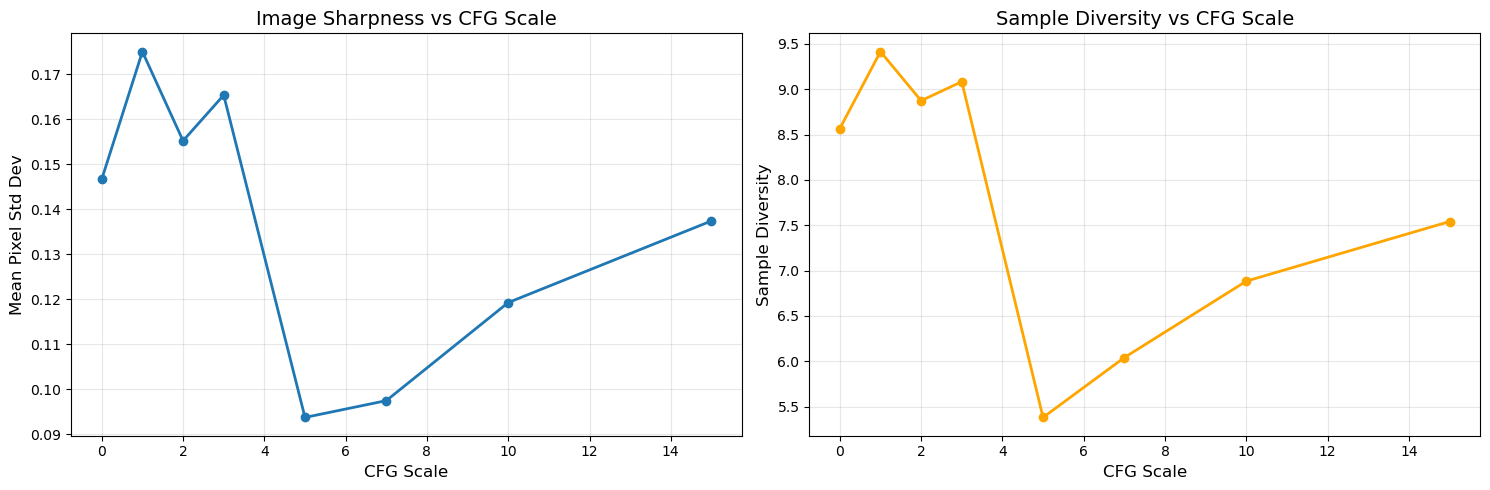


Key Insights:
- Higher CFG scale typically increases sharpness but may reduce diversity
- Sweet spot is usually between 2.0-5.0 for balanced quality and diversity


In [18]:
# Generate samples at different CFG scales for analysis
cfg_scales_analysis = [0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0]
samples_per_scale = 20
target_class = 5

print(f"Analyzing CFG scales for class {target_class}...")

results = {'cfg_scale': [], 'mean_pixel_std': [], 'sample_diversity': []}

for cfg_scale in cfg_scales_analysis:
    class_labels = torch.full((samples_per_scale,), target_class).to(device)
    
    with torch.no_grad():
        samples = cfg_attn.sample(
            num_samples=samples_per_scale,
            class_labels=class_labels,
            method='ddim',
            num_inference_steps=50,
            cfg_scale=cfg_scale
        )
    
    # Calculate metrics
    mean_pixel_std = samples.std(dim=0).mean().item()
    sample_diversity = torch.cdist(samples.flatten(1), samples.flatten(1)).mean().item()
    
    results['cfg_scale'].append(cfg_scale)
    results['mean_pixel_std'].append(mean_pixel_std)
    results['sample_diversity'].append(sample_diversity)
    
    print(f"  CFG={cfg_scale:5.1f} | Pixel Std: {mean_pixel_std:.4f} | Diversity: {sample_diversity:.4f}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(results['cfg_scale'], results['mean_pixel_std'], marker='o', linewidth=2)
ax1.set_xlabel('CFG Scale', fontsize=12)
ax1.set_ylabel('Mean Pixel Std Dev', fontsize=12)
ax1.set_title('Image Sharpness vs CFG Scale', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(results['cfg_scale'], results['sample_diversity'], marker='o', linewidth=2, color='orange')
ax2.set_xlabel('CFG Scale', fontsize=12)
ax2.set_ylabel('Sample Diversity', fontsize=12)
ax2.set_title('Sample Diversity vs CFG Scale', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("- Higher CFG scale typically increases sharpness but may reduce diversity")
print("- Sweet spot is usually between 2.0-5.0 for balanced quality and diversity")

## 10. Visualize Denoising Process with CFG

Generating denoising visualization...


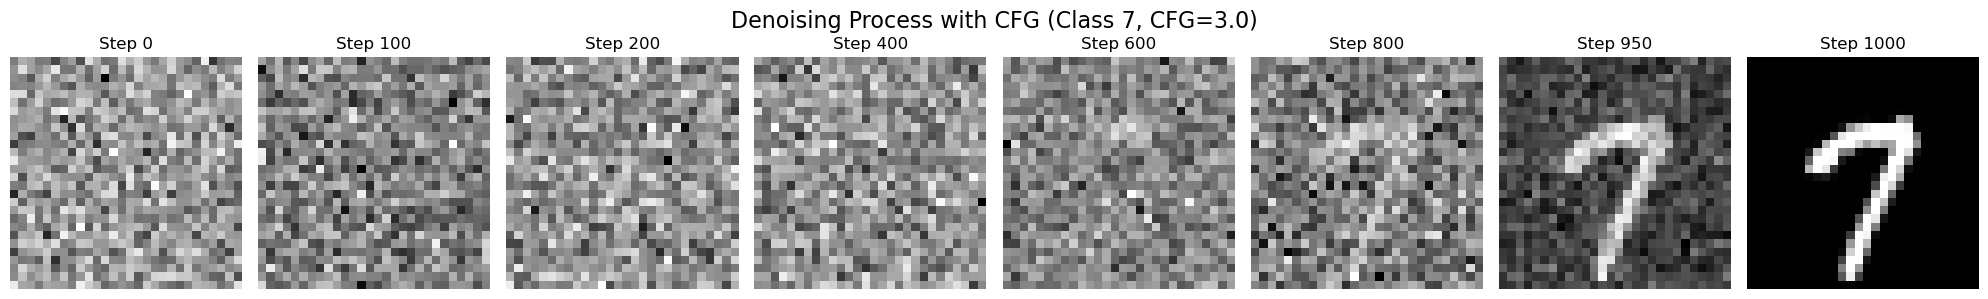

In [19]:
# Generate with intermediate steps
print("Generating denoising visualization...")

class_label = torch.tensor([7]).to(device)

with torch.no_grad():
    final, all_steps = cfg_attn.sample(
        num_samples=1,
        class_labels=class_label,
        method='ddpm',
        cfg_scale=3.0,
        return_all_steps=True
    )

# Show progression
steps_to_show = [0, 100, 200, 400, 600, 800, 950, 1000]
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(20, 3))

for idx, step in enumerate(steps_to_show):
    axes[idx].imshow(all_steps[step][0, 0].cpu(), cmap='gray')
    axes[idx].axis('off')
    axes[idx].set_title(f'Step {step}', fontsize=12)

plt.suptitle(f'Denoising Process with CFG (Class {class_label.item()}, CFG=3.0)', fontsize=16)
plt.tight_layout()
plt.show()

## 11. Unconditional vs Conditional Sampling

Comparing unconditional vs conditional sampling...


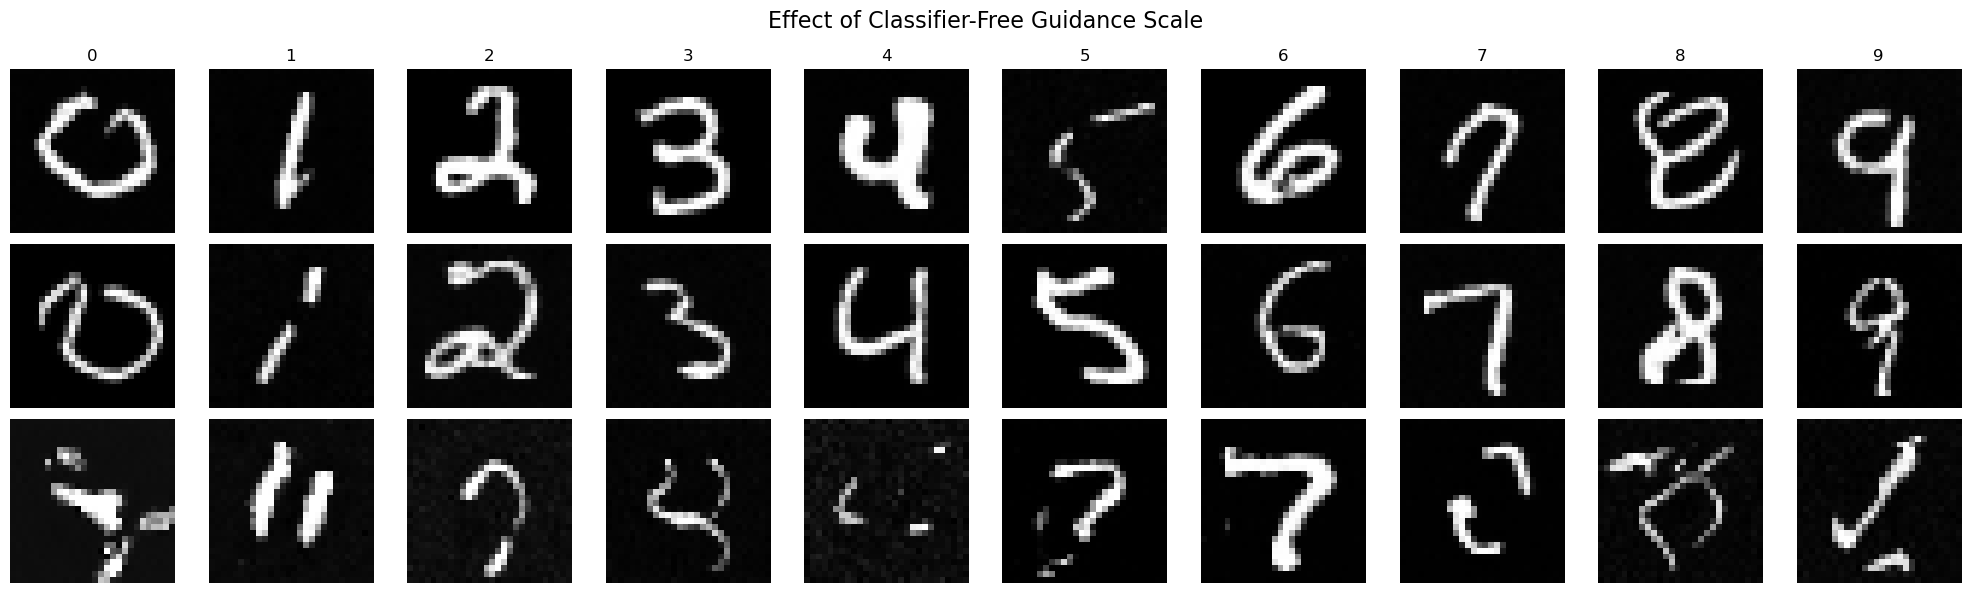

In [21]:
# Compare unconditional (CFG=0) vs conditional (CFG>0) samples
print("Comparing unconditional vs conditional sampling...")

class_labels = torch.arange(10).to(device)

fig, axes = plt.subplots(3, 10, figsize=(20, 6))

# Row 1: Unconditional (CFG=0)
with torch.no_grad():
    samples_uncond = cfg_attn.sample(
        num_samples=10,
        class_labels=class_labels,
        method='ddim',
        num_inference_steps=50,
        cfg_scale=0.0
    )

# Row 2: Low CFG
with torch.no_grad():
    samples_low_cfg = cfg_attn.sample(
        num_samples=10,
        class_labels=class_labels,
        method='ddim',
        num_inference_steps=50,
        cfg_scale=3.0
    )

# Row 3: High CFG
with torch.no_grad():
    samples_high_cfg = cfg_attn.sample(
        num_samples=10,
        class_labels=class_labels,
        method='ddim',
        num_inference_steps=50,
        cfg_scale=7.0
    )

for i in range(10):
    axes[0, i].imshow(samples_uncond[i, 0].cpu(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'{i}', fontsize=12)
    
    axes[1, i].imshow(samples_low_cfg[i, 0].cpu(), cmap='gray')
    axes[1, i].axis('off')
    
    axes[2, i].imshow(samples_high_cfg[i, 0].cpu(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('CFG=0.0\n(Uncond)', fontsize=12, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('CFG=3.0', fontsize=12, rotation=0, ha='right', va='center')
axes[2, 0].set_ylabel('CFG=7.0', fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle('Effect of Classifier-Free Guidance Scale', fontsize=16)
plt.tight_layout()
plt.show()

## 12. Summary and Conclusions

### Key Findings:

1. **Conditioning Methods**:
   - Input Concatenation: Simpler, spatially tiled class embeddings
   - Cross-Attention: More flexible, allows model to attend to class information
   - Both methods produce high-quality class-conditional samples

2. **CFG Scale Effects**:
   - CFG = 0: Pure conditional generation (unconditional component ignored)
   - CFG = 1-3: Balanced quality and diversity
   - CFG = 5-7: Higher quality, stronger class adherence
   - CFG > 10: Maximum quality but reduced diversity

3. **Quality vs Diversity Trade-off**:
   - Lower CFG: More diverse but potentially less class-consistent
   - Higher CFG: More class-consistent but less diverse
   - Sweet spot typically 2.0-5.0 for most applications

4. **Training Insights**:
   - CFG dropout of 10% works well for learning unconditional generation
   - Cross-attention provides more flexible conditioning
   - Both methods converge to similar quality with proper training

## 13. Save Results

In [22]:
import torchvision

# Save sample images
os.makedirs('../plots/cfg', exist_ok=True)

# Save class-conditional samples
torchvision.utils.save_image(
    samples_concat,
    '../plots/cfg/class_conditional_concat.png',
    nrow=10,
    normalize=True
)

torchvision.utils.save_image(
    samples_attn,
    '../plots/cfg/class_conditional_attn.png',
    nrow=10,
    normalize=True
)

print("✓ Sample images saved to plots/cfg/")
print("\n✅ Experiment complete!")

✓ Sample images saved to plots/cfg/

✅ Experiment complete!
